# Datasaurus Dozen (Python)

**Package situation:** The curated datasets ship as the R package [**`datasauRus`**](https://cran.r-project.org/package=datasauRus) (CRAN). There is **no widely used PyPI package** that only bundles these thirteen sets; authors distribute **CSV** (e.g. [OpenIntro](https://www.openintro.org/data/index.php?data=datasaurus), [TidyTuesday mirror](https://github.com/rfordatascience/tidytuesday/tree/master/data/2020/2020-10-13)).

A related **Python** tool is [**Data Morph**](https://github.com/stefanrmmr/data-morph) (morph shapes while preserving stats)—different goal than “just load the dozen”.

Below: **load the CSV once**, then scatter **all thirteen** variants and check that **summary statistics** stay almost identical while **shapes** differ (after Alberto Cairo / Matejka & Fitzmaurice, CHI 2017).

In [1]:
import io
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

URL = (
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/"
    "master/data/2020/2020-10-13/datasaurus.csv"
)

with urllib.request.urlopen(URL, timeout=30) as resp:
    df = pd.read_csv(io.BytesIO(resp.read()))

df.head()

,dataset,x,y
0,dino,55.3846,97.1795
1,dino,51.5385,96.0256
2,dino,46.1538,94.4872
3,dino,42.8205,91.4103
4,dino,40.7692,88.3333


## Summary statistics by `dataset`

Means, variances, and correlation should match across rows (up to rounding in the source CSV).

In [2]:
def summarize(g):
    x, y = g["x"], g["y"]
    return pd.Series(
        {
            "n": len(x),
            "mean_x": x.mean(),
            "mean_y": y.mean(),
            "var_x": x.var(ddof=1),
            "var_y": y.var(ddof=1),
            "corr_xy": x.corr(y),
        }
    )


stats = pd.DataFrame(
    {name: summarize(g) for name, g in df.groupby("dataset", sort=False)}
).T.rename_axis("dataset")
stats.round(3)

,n,mean_x,mean_y,var_x,var_y,corr_xy
dataset,,,,,,
dino,142.0,54.263,47.832,281.070,725.516,-0.064
away,142.0,54.266,47.835,281.227,725.750,-0.064
h_lines,142.0,54.261,47.830,281.095,725.757,-0.062
v_lines,142.0,54.270,47.837,281.232,725.639,-0.069
x_shape,142.0,54.260,47.840,281.231,725.225,-0.066
star,142.0,54.267,47.840,281.198,725.240,-0.063
high_lines,142.0,54.269,47.835,281.122,725.763,-0.069
dots,142.0,54.260,47.840,281.157,725.235,-0.060
circle,142.0,54.267,47.838,280.898,725.227,-0.068


## Small multiples: same stats, different shapes

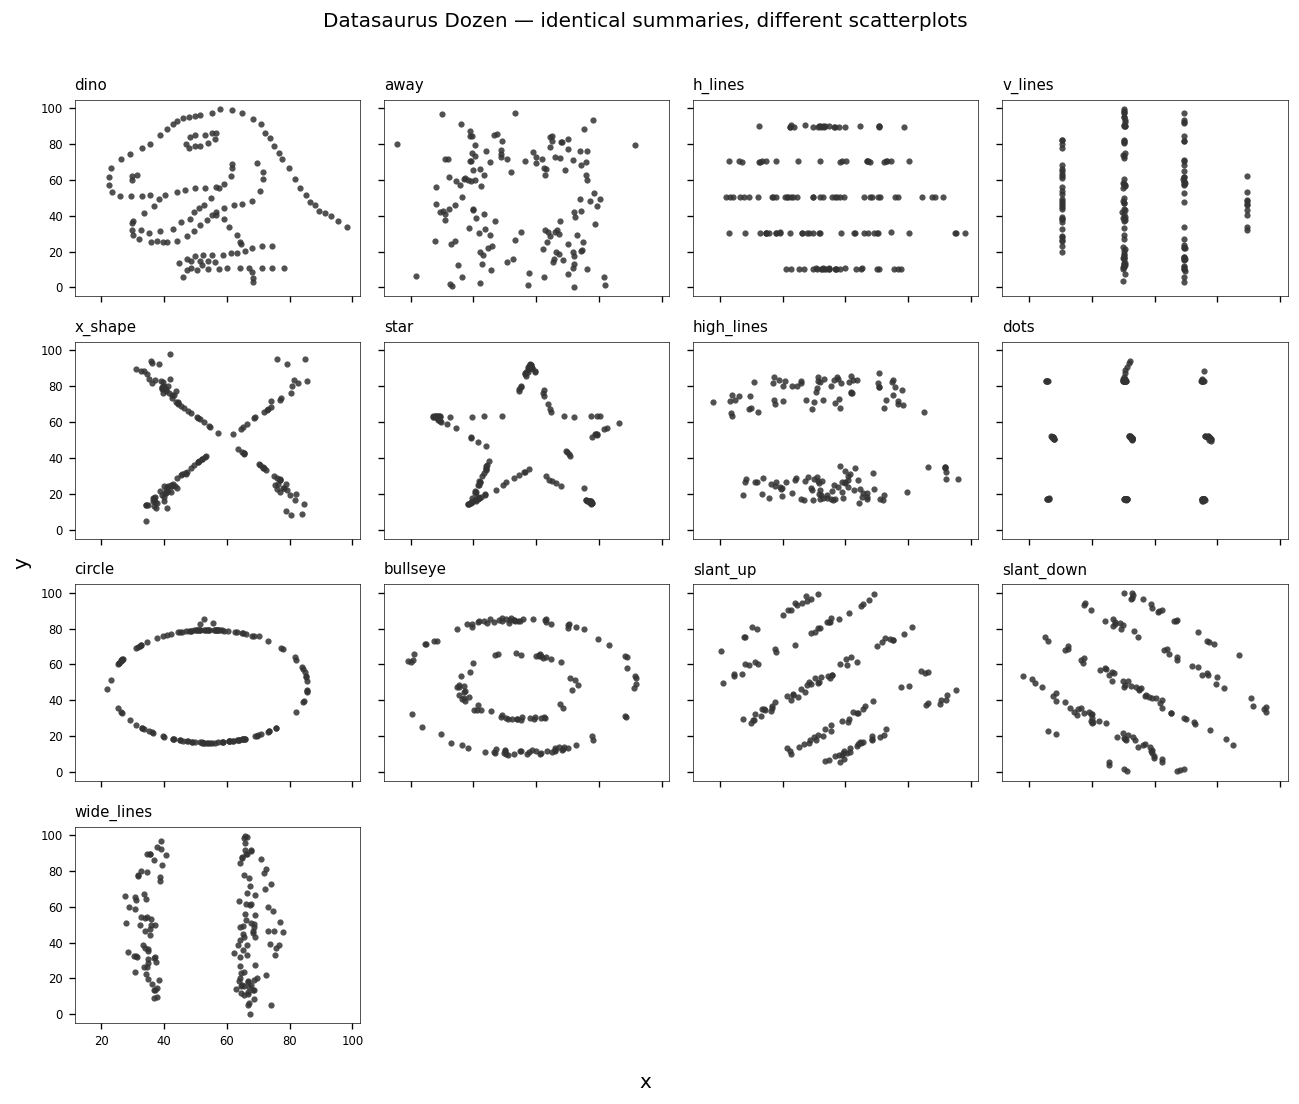

In [3]:
datasets = list(df["dataset"].unique())
n = len(datasets)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(11, 9), sharex=True, sharey=True, dpi=120)
axes = np.atleast_1d(axes).ravel()

for ax, name in zip(axes, datasets):
    sub = df.loc[df["dataset"] == name]
    ax.scatter(sub["x"], sub["y"], s=14, c="0.2", alpha=0.85, linewidths=0)
    ax.set_title(name, fontsize=9, loc="left")
    ax.tick_params(labelsize=7)
    for s in ax.spines.values():
        s.set_linewidth(0.4)

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle("Datasaurus Dozen — identical summaries, different scatterplots", fontsize=12, y=1.01)
fig.supxlabel("x")
fig.supylabel("y")
plt.tight_layout()
plt.show()

## Simulating data (two angles)

The Wikipedia article on **Datasaurus dozen** summarises the construction algorithm (after Matejka & Fitzmaurice, CHI 2017) in pseudocode—**~200 000 iterations per target shape** in the original work, not what we can afford in a browser notebook:

```text
current_ds ← initial_ds
for x iterations, do:
    test_ds ← perturb(current_ds, temp)
    if similar_enough(test_ds, initial_ds):
        current_ds ← test_ds

function perturb(ds, temp):
    loop:
        test ← move_random_points(ds)
        if fit(test) > fit(ds) or temp > random():
            return test
```

Here `initial_ds` is the seed scatter, `similar_enough` checks summary statistics, `fit` scores proximity to a desired silhouette, and `temp` is the annealing temperature ([Wikipedia: *Datasaurus dozen* — Creation](https://en.wikipedia.org/wiki/Datasaurus_dozen#Creation)).

**1 — Parametric bootstrap (fast):** Treat the reference cloud as a **bivariate normal** with the same sample mean and covariance, then **draw new synthetic samples**. Summaries stay in the right ballpark, but the shape stays “elliptical”—this is *not* that construction.

**2 — Same pseudocode, toy parameters:** The code cell below defines `move_random_points`, `perturb`, `fit`, and `similar_enough`, then runs a **short** outer loop with a **circle** target and loose tolerances. It mirrors the Wikipedia structure, not the full research pipeline.

MVN simulation — mean absolute error vs dino stats (over 400 draws): means [1.19469866 1.76422417], vars [27.42122768 64.81558905], |Δcorr| 0.0655


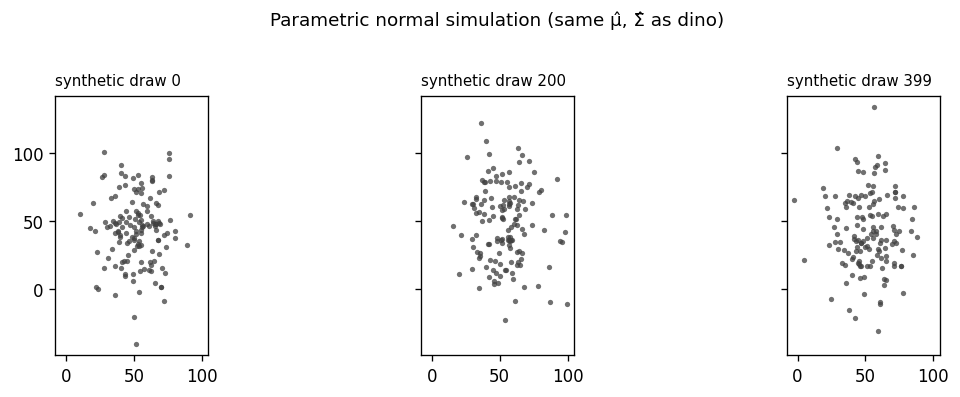

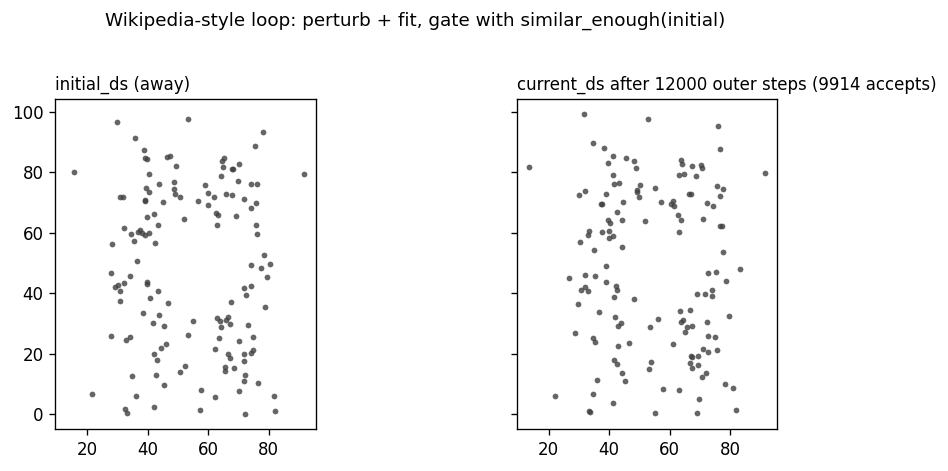

initial stats (frozen): [ 5.42660e+01  4.78350e+01  2.81227e+02  7.25750e+02 -6.40000e-02]
dino ref (compare):     [ 5.42630e+01  4.78320e+01  2.81070e+02  7.25516e+02 -6.40000e-02]
current_ds stats:       [ 5.43650e+01  4.78640e+01  2.79162e+02  7.13751e+02 -6.20000e-02]


In [4]:
rng = np.random.default_rng(7)


def vec_stats(xy: np.ndarray) -> np.ndarray:
    x, y = xy[:, 0], xy[:, 1]
    return np.array(
        [
            x.mean(),
            y.mean(),
            x.var(ddof=1),
            y.var(ddof=1),
            np.corrcoef(x, y)[0, 1],
        ]
    )


def stats_match(s: np.ndarray, ref: np.ndarray, mean_atol=0.6, var_atol=12.0, corr_atol=0.12) -> bool:
    return bool(
        np.allclose(s[:2], ref[:2], atol=mean_atol)
        and np.allclose(s[2:4], ref[2:4], atol=var_atol)
        and abs(s[4] - ref[4]) < corr_atol
    )


# --- (1) Parametric MVN simulation (same μ̂, Σ̂ as dino) ---
dino_xy = df.loc[df["dataset"] == "dino", ["x", "y"]].to_numpy(dtype=float)
ref = vec_stats(dino_xy)
n = dino_xy.shape[0]
mean_hat = dino_xy.mean(axis=0)
cov_hat = np.cov(dino_xy, rowvar=False)

B = 400
synth = rng.multivariate_normal(mean_hat, cov_hat, size=(B, n))
sim_stats = np.stack([vec_stats(synth[b]) for b in range(B)])
print(
    "MVN simulation — mean absolute error vs dino stats "
    f"(over {B} draws): means {np.abs(sim_stats[:, :2] - ref[:2]).mean(0)}, "
    f"vars {np.abs(sim_stats[:, 2:4] - ref[2:4]).mean(0)}, "
    f"|Δcorr| {np.abs(sim_stats[:, 4] - ref[4]).mean():.4f}"
)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.2), dpi=120, sharex=True, sharey=True)
for ax, b in zip(axes, [0, B // 2, B - 1]):
    ax.scatter(synth[b, :, 0], synth[b, :, 1], s=10, c="0.25", alpha=0.75, linewidths=0)
    ax.set_title(f"synthetic draw {b}", fontsize=9, loc="left")
    ax.set_aspect("equal", adjustable="box")
fig.suptitle("Parametric normal simulation (same μ̂, Σ̂ as dino)", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# --- (2) Wikipedia pseudocode structure (Matejka & Fitzmaurice; toy parameters) ---
# Outer:  current_ds ← initial_ds
#          test_ds ← perturb(current_ds, temp);  if similar_enough(test_ds, initial_ds): current_ds ← test_ds
# Inner perturb: move_random_points; accept if fit(test) > fit(ds) OR random() < temp (see Wikipedia).


def move_random_points(ds: np.ndarray, rng: np.random.Generator, sigma: float) -> np.ndarray:
    out = ds.copy()
    i = int(rng.integers(0, len(out)))
    out[i] = out[i] + rng.normal(0, sigma, size=2)
    return out


def fit(xy: np.ndarray, target_xy: np.ndarray) -> float:
    """Higher = closer to target template (same point index)."""
    return -float(np.mean(np.sum((xy - target_xy) ** 2, axis=1)))


def perturb(ds: np.ndarray, temp: float, target_xy: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    inner_loops = 40
    for _ in range(inner_loops):
        test = move_random_points(ds, rng, sigma=0.22 * max(temp, 0.05))
        # Wikipedia: "temp > random()" — interpret as random accept with probability ~temp when fit does not improve
        if fit(test, target_xy) > fit(ds, target_xy) or rng.random() < temp:
            return test
    return ds.copy()


def similar_enough(test_ds: np.ndarray, initial_stats: np.ndarray) -> bool:
    """Wikipedia: compare whether test_ds has (approximately) the same summaries as initial_ds."""
    return stats_match(vec_stats(test_ds), initial_stats)


initial_ds = df.loc[df["dataset"] == "away", ["x", "y"]].to_numpy(dtype=float)
initial_stats = vec_stats(initial_ds.copy())
current_ds = initial_ds.copy()

cx, cy = mean_hat
R = np.sqrt(((dino_xy - mean_hat) ** 2).sum(axis=1)).mean() * 1.15
theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
target_xy = np.column_stack([cx + R * np.cos(theta), cy + R * np.sin(theta)])

temp, accepted = 2.0, 0
iters = 12_000
for _ in range(iters):
    test_ds = perturb(current_ds, temp, target_xy, rng)
    if similar_enough(test_ds, initial_stats):
        current_ds = test_ds
        accepted += 1
    temp *= 0.9996

fig, (a0, a1) = plt.subplots(1, 2, figsize=(8.5, 3.8), dpi=120, sharex=True, sharey=True)
a0.scatter(initial_ds[:, 0], initial_ds[:, 1], s=12, c="0.25", alpha=0.8, linewidths=0)
a0.set_title("initial_ds (away)", fontsize=10, loc="left")
a1.scatter(current_ds[:, 0], current_ds[:, 1], s=12, c="0.25", alpha=0.8, linewidths=0)
a1.set_title(f"current_ds after {iters} outer steps ({accepted} accepts)", fontsize=10, loc="left")
for ax in (a0, a1):
    ax.set_aspect("equal", adjustable="box")
fig.suptitle("Wikipedia-style loop: perturb + fit, gate with similar_enough(initial)", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print("initial stats (frozen):", np.round(initial_stats, 3))
print("dino ref (compare):    ", np.round(ref, 3))
print("current_ds stats:      ", np.round(vec_stats(current_ds), 3))


## Offline use

Save once after download:

```python
df.to_csv("datasaurus.csv", index=False)
```

Then replace the `urllib` block with `pd.read_csv("datasaurus.csv")`.